# Passport-page visual embeddings with a multi-scale CNN

**Goal:** transform every document-page image into one fixed-length visual vector suitable for passport-presence classification.

## Why a plain flattened or resized page is not enough

An A4 scan may be roughly 2,500 × 3,500 pixels, while a passport can occupy only part of it. Resizing the whole page directly to 224 × 224 destroys small but important evidence such as the MRZ, portrait/layout relationship, security patterns, and document borders. Flattening raw pixels also creates a huge, position-sensitive vector and does not learn useful visual features.

## Representation used in this notebook

1. **Full-page view** — keeps the page-level context.
2. **Overlapping tiles at two scales** — preserves local passport structure and detail.
3. **Pretrained EfficientNet-B0 CNN** — converts each view to a semantic 1,280-value feature vector.
4. **Multi-instance pooling** — mean, maximum, and standard deviation across tile vectors preserve common, strong, and variable local evidence.
5. The output is `[full_page, tile_mean, tile_max, tile_std]`, a **5,120-value vector per page**.

This is a good starting point when only page-level labels are available. If passport bounding boxes can be labeled, object detection is usually the stronger final solution because it learns where the passport is.

Official references: [TorchVision EfficientNet-B0](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b0.html), [PyTorch transfer learning tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html), and [TorchVision object-detection fine-tuning tutorial](https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html).


## Alternatives and when to use them

| Method | Advantages | Main limitation | When to choose it |
|---|---|---|---|
| Whole-page CNN only | Simple and fast | Small passports lose detail after resizing | Passport normally fills most of the page |
| **Full page + overlapping tiles (this notebook)** | Works with page labels; keeps context and local detail; fixed vector size | More inference time; does not explicitly localize | Best starting point for the described dataset |
| Object detector (Faster R-CNN/RetinaNet/YOLO family) | Localizes passport and ignores unrelated page content | Requires passport bounding-box labels | Best production approach when boxes can be annotated |
| CNN vector + OCR/MRZ features | Visual layout plus very strong textual evidence | More pipeline components; OCR can fail on blur/rotation | Useful when precision must be high and OCR already exists |

Do not train a CNN from random initialization unless the dataset is large. Start from ImageNet weights, first train a small classifier on frozen embeddings, and then fine-tune the last CNN blocks if validation results justify it.


## 1. Installation

Run the next cell only if the packages are missing. Install the CUDA-compatible PyTorch build for your environment when a GPU is available.


In [6]:
%pip install -q torch torchvision pillow numpy pandas scikit-learn matplotlib tqdm joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and configuration

Expected input:

- JPG/JPEG/PNG pages under `dataset_images/` (subdirectories are allowed).
- Optional `labels.csv` with `relative_path,label` and optionally `document_id`.
- `label` should be `1` for a page containing a passport and `0` otherwise.

`document_id` is strongly recommended when several pages came from the same PDF/Word file. It prevents pages from the same source document appearing in both training and validation.


In [1]:
from contextlib import nullcontext
from pathlib import Path
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("dataset_images")
OUTPUT_DIR = Path("passport_vector_output")
LABELS_FILE = Path("passport_page_labels.csv")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# Relative tile sides: 0.38 and 0.60 of the page's shorter side.
# The smaller scale retains detail; the larger scale can contain the whole passport.
TILE_SCALES = (0.38, 0.60)
TILE_OVERLAP = 0.25
MAX_TILES_PER_ROTATION = 32

# Use (0, 90, 180, 270) if pages/passports may be rotated.
# More angles improve robustness but increase runtime almost linearly.
ROTATIONS = (0,)

VIEW_BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Device:", DEVICE)


C:\Users\user\PycharmProjects\Project.DS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 3. Find the input images


In [2]:
image_paths = sorted(
    p for p in DATA_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

files_df = pd.DataFrame({
    "relative_path": [p.relative_to(DATA_DIR).as_posix() for p in image_paths],
    "image_name": [p.name for p in image_paths],
    "image_path": [str(p) for p in image_paths],
})

print(f"Found {len(files_df):,} images")
display(files_df.head())

if files_df.empty:
    raise FileNotFoundError(
        f"No JPG/JPEG/PNG images were found under: {DATA_DIR.resolve()}"
    )


Found 141 images


,relative_path,image_name,image_path
0,PDF_Edge_Case_11_page_1.jpg,PDF_Edge_Case_11_page_1.jpg,dataset_images\PDF_Edge_Case_11_page_1.jpg
1,PDF_Edge_Case_12_page_1.jpg,PDF_Edge_Case_12_page_1.jpg,dataset_images\PDF_Edge_Case_12_page_1.jpg
2,PDF_Edge_Case_12_page_2.jpg,PDF_Edge_Case_12_page_2.jpg,dataset_images\PDF_Edge_Case_12_page_2.jpg
3,PDF_Edge_Case_12_page_3.jpg,PDF_Edge_Case_12_page_3.jpg,dataset_images\PDF_Edge_Case_12_page_3.jpg
4,PDF_Edge_Case_12_page_4.jpg,PDF_Edge_Case_12_page_4.jpg,dataset_images\PDF_Edge_Case_12_page_4.jpg


## 4. Create full-page and overlapping local views

The blank-tile filter removes almost empty margins. If there are more than `MAX_TILES_PER_ROTATION`, the most informative tiles are retained using simple ink and intensity-variation scores. This happens before CNN inference and only reduces wasted computation.


In [3]:
def open_rgb(path):
    image = Image.open(path)
    image = ImageOps.exif_transpose(image)
    return image.convert("RGB")


def letterbox_square(image, fill=(255, 255, 255)):
    # Pad an image to a square without changing its aspect ratio.
    side = max(image.size)
    canvas = Image.new("RGB", (side, side), fill)
    x = (side - image.width) // 2
    y = (side - image.height) // 2
    canvas.paste(image, (x, y))
    return canvas


def sliding_positions(length, crop_size, stride):
    if length <= crop_size:
        return [0]
    positions = list(range(0, length - crop_size + 1, stride))
    last = length - crop_size
    if positions[-1] != last:
        positions.append(last)
    return positions


def tile_information_score(tile):
    gray = np.asarray(tile.convert("L").resize((96, 96)), dtype=np.float32) / 255.0
    ink_fraction = float((gray < 0.96).mean())
    intensity_std = float(gray.std())
    return intensity_std + 0.5 * ink_fraction, ink_fraction, intensity_std


def make_tiles(image, scales=TILE_SCALES, overlap=TILE_OVERLAP, max_tiles=32):
    width, height = image.size
    short_side = min(width, height)
    candidates = []

    for scale in scales:
        crop_size = int(round(short_side * scale))
        crop_size = max(256, min(crop_size, short_side))
        stride = max(1, int(round(crop_size * (1.0 - overlap))))

        xs = sliding_positions(width, crop_size, stride)
        ys = sliding_positions(height, crop_size, stride)

        for y in ys:
            for x in xs:
                tile = image.crop((x, y, x + crop_size, y + crop_size))
                score, ink, std = tile_information_score(tile)

                # Keep content and reject almost-white page margins.
                if ink >= 0.01 or std >= 0.03:
                    candidates.append({
                        "tile": tile,
                        "score": score,
                        "scale": scale,
                        "box": (x, y, x + crop_size, y + crop_size),
                    })

    candidates.sort(key=lambda item: item["score"], reverse=True)
    return candidates[:max_tiles]


def create_page_views(image):
    # Return one page view and selected local tiles from configured rotations.
    page_view = letterbox_square(image)
    tile_records = []

    for angle in ROTATIONS:
        rotated = image if angle == 0 else image.rotate(angle, expand=True, fillcolor="white")
        records = make_tiles(
            rotated,
            max_tiles=MAX_TILES_PER_ROTATION,
        )
        for record in records:
            record["angle"] = angle
        tile_records.extend(records)

    # Ensure pooling always has at least one local view.
    if not tile_records:
        tile_records = [{
            "tile": page_view,
            "score": 0.0,
            "scale": 1.0,
            "box": (0, 0, image.width, image.height),
            "angle": 0,
        }]

    return page_view, tile_records


## 5. Inspect the tiles before extracting vectors


Image: dataset_images\PDF_Edge_Case_11_page_1.jpg
Original size: (1654, 2339)
Selected local views: 26


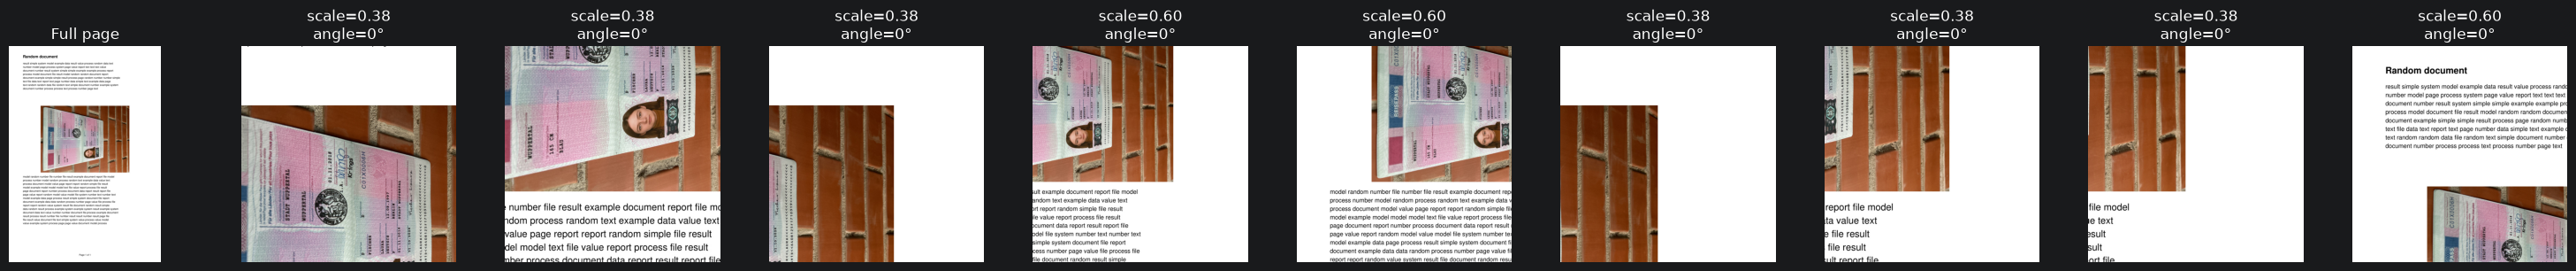

In [4]:
sample_path = image_paths[0]
sample_image = open_rgb(sample_path)
sample_page_view, sample_tiles = create_page_views(sample_image)

print("Image:", sample_path)
print("Original size:", sample_image.size)
print("Selected local views:", len(sample_tiles))

n_show = min(9, len(sample_tiles))
fig, axes = plt.subplots(1, n_show + 1, figsize=(3 * (n_show + 1), 3))
axes[0].imshow(sample_image)
axes[0].set_title("Full page")
axes[0].axis("off")

for ax, record in zip(axes[1:], sample_tiles[:n_show]):
    ax.imshow(record["tile"])
    ax.set_title(f"scale={record['scale']:.2f}\nangle={record['angle']}°")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6. Load the pretrained convolutional encoder

EfficientNet-B0 is compact and returns a 1,280-dimensional feature vector after global pooling. Its final ImageNet classification layer is removed. The official weight-specific preprocessing is used.


In [5]:
weights = EfficientNet_B0_Weights.DEFAULT
preprocess = weights.transforms()

encoder = efficientnet_b0(weights=weights)
encoder.classifier = nn.Identity()
encoder = encoder.to(DEVICE).eval()

EMBEDDING_DIM = 1280
OUTPUT_VECTOR_DIM = EMBEDDING_DIM * 4

print("Per-view embedding:", EMBEDDING_DIM)
print("Per-page output vector:", OUTPUT_VECTOR_DIM)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\user/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 7.85MB/s]


Per-view embedding: 1280
Per-page output vector: 5120


## 7. Convert one page to one fixed-length vector

Each per-view embedding is L2-normalized first. The final concatenated vector is normalized again, which usually makes the downstream classifier more stable.


In [6]:
def encode_views(pil_images, batch_size=VIEW_BATCH_SIZE):
    batches = []

    for start in range(0, len(pil_images), batch_size):
        current = pil_images[start:start + batch_size]
        tensor = torch.stack([preprocess(image) for image in current]).to(DEVICE)

        amp = (
            torch.autocast(device_type="cuda", dtype=torch.float16)
            if DEVICE.type == "cuda"
            else nullcontext()
        )

        with torch.inference_mode(), amp:
            embeddings = encoder(tensor)
            embeddings = F.normalize(embeddings.float(), p=2, dim=1)

        batches.append(embeddings.cpu())

    return torch.cat(batches, dim=0)


def image_to_vector(image):
    page_view, tile_records = create_page_views(image)

    page_embedding = encode_views([page_view])[0]
    tile_embeddings = encode_views([item["tile"] for item in tile_records])

    tile_mean = tile_embeddings.mean(dim=0)
    tile_max = tile_embeddings.max(dim=0).values
    tile_std = tile_embeddings.std(dim=0, unbiased=False)

    vector = torch.cat([
        page_embedding,
        tile_mean,
        tile_max,
        tile_std,
    ])
    vector = F.normalize(vector, p=2, dim=0)

    return vector.numpy().astype(np.float32), len(tile_records)


sample_vector, sample_tile_count = image_to_vector(sample_image)
print("Vector shape:", sample_vector.shape)
print("Tile count:", sample_tile_count)
print("L2 norm:", np.linalg.norm(sample_vector))


Vector shape: (5120,)
Tile count: 26
L2 norm: 0.99999994


## 8. Transform the complete dataset

The output is saved in compressed NumPy format. It contains:

- `X`: matrix with one 5,120-value row per successfully processed page;
- `relative_path`: stable image identifiers;
- `image_name`: original basenames.

Failed images are recorded in `embedding_metadata.csv` instead of stopping the complete run.


In [7]:
vectors = []
metadata = []

for row in tqdm(files_df.itertuples(index=False), total=len(files_df), desc="Pages"):
    try:
        image = open_rgb(row.image_path)
        vector, tile_count = image_to_vector(image)
        vectors.append(vector)
        metadata.append({
            "relative_path": row.relative_path,
            "image_name": row.image_name,
            "image_path": row.image_path,
            "width": image.width,
            "height": image.height,
            "tile_count": tile_count,
            "status": "ok",
            "error": "",
            "vector_row": len(vectors) - 1,
        })
    except Exception as exc:
        metadata.append({
            "relative_path": row.relative_path,
            "image_name": row.image_name,
            "image_path": row.image_path,
            "width": np.nan,
            "height": np.nan,
            "tile_count": 0,
            "status": "failed",
            "error": repr(exc),
            "vector_row": np.nan,
        })

metadata_df = pd.DataFrame(metadata)
ok_df = metadata_df.loc[metadata_df["status"] == "ok"].copy()

if not vectors:
    raise RuntimeError("No image was transformed successfully.")

X = np.stack(vectors).astype(np.float32)

np.savez_compressed(
    OUTPUT_DIR / "page_embeddings.npz",
    X=X,
    relative_path=ok_df["relative_path"].to_numpy(dtype=str),
    image_name=ok_df["image_name"].to_numpy(dtype=str),
)
metadata_df.to_csv(OUTPUT_DIR / "embedding_metadata.csv", index=False, encoding="utf-8-sig")

print("Embedding matrix:", X.shape)
print("Failures:", int((metadata_df["status"] == "failed").sum()))
print("Saved to:", OUTPUT_DIR.resolve())
display(metadata_df.head())


Pages: 100%|██████████| 141/141 [05:42<00:00,  2.43s/it]


Embedding matrix: (141, 5120)
Failures: 0
Saved to: C:\Users\user\PycharmProjects\Project.DS\passport_vector_output


,relative_path,image_name,image_path,width,height,tile_count,status,error,vector_row
0,PDF_Edge_Case_11_page_1.jpg,PDF_Edge_Case_11_page_1.jpg,dataset_images\PDF_Edge_Case_11_page_1.jpg,1654,2339,26,ok,,0
1,PDF_Edge_Case_12_page_1.jpg,PDF_Edge_Case_12_page_1.jpg,dataset_images\PDF_Edge_Case_12_page_1.jpg,1654,2339,20,ok,,1
2,PDF_Edge_Case_12_page_2.jpg,PDF_Edge_Case_12_page_2.jpg,dataset_images\PDF_Edge_Case_12_page_2.jpg,1654,2339,20,ok,,2
3,PDF_Edge_Case_12_page_3.jpg,PDF_Edge_Case_12_page_3.jpg,dataset_images\PDF_Edge_Case_12_page_3.jpg,1654,2339,26,ok,,3
4,PDF_Edge_Case_12_page_4.jpg,PDF_Edge_Case_12_page_4.jpg,dataset_images\PDF_Edge_Case_12_page_4.jpg,1654,2339,20,ok,,4


## 9. Optional baseline classifier

This baseline tests whether the frozen vectors separate passport/non-passport pages. It is intentionally simple. A regularized logistic regression is easier to validate than immediately fine-tuning the complete CNN.

If `document_id` exists, the split is made by source document to avoid leakage. Otherwise the split is stratified by page label; this is acceptable only when each image is independent.


Split: stratified by page label (no document grouping)
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        23
           1     1.0000    1.0000    1.0000         6

    accuracy                         1.0000        29
   macro avg     1.0000    1.0000    1.0000        29
weighted avg     1.0000    1.0000    1.0000        29

ROC AUC: 1.0


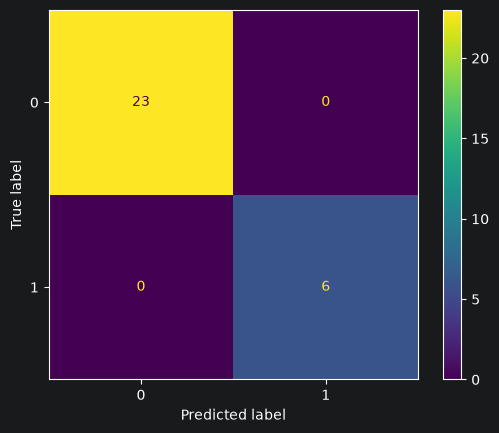

Saved baseline classifier.


In [15]:
LABELS_FILE = Path("passport_vector_output/labels.csv")
if not LABELS_FILE.exists():
    print(
        "labels.csv was not found. Create it with columns:\n"
        "relative_path,label\n"
        "optionally add document_id to prevent source-document leakage."
    )
else:
    labels_df = pd.read_csv(LABELS_FILE, encoding="utf-8-sig")
    required = {"relative_path", "label"}
    missing = required - set(labels_df.columns)
    if missing:
        raise ValueError(f"Missing label columns: {sorted(missing)}")

    model_df = ok_df[["relative_path", "vector_row"]].merge(
        labels_df,
        on="relative_path",
        how="inner",
        validate="one_to_one",
    )

    row_ids = model_df["vector_row"].astype(int).to_numpy()
    X_model = X[row_ids]
    y = model_df["label"].astype(int).to_numpy()

    if "document_id" in model_df.columns:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
        train_idx, test_idx = next(
            splitter.split(X_model, y, groups=model_df["document_id"])
        )
        split_type = "grouped by document_id"
    else:
        all_idx = np.arange(len(model_df))
        train_idx, test_idx = train_test_split(
            all_idx,
            test_size=0.20,
            random_state=SEED,
            stratify=y,
        )
        split_type = "stratified by page label (no document grouping)"

    classifier = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED,
        ),
    )
    classifier.fit(X_model[train_idx], y[train_idx])

    predictions = classifier.predict(X_model[test_idx])
    probabilities = classifier.predict_proba(X_model[test_idx])[:, 1]

    print("Split:", split_type)
    print(classification_report(y[test_idx], predictions, digits=4, zero_division=0))

    if len(np.unique(y[test_idx])) == 2:
        print("ROC AUC:", round(roc_auc_score(y[test_idx], probabilities), 4))

    ConfusionMatrixDisplay.from_predictions(y[test_idx], predictions)
    plt.show()

    joblib.dump(classifier, OUTPUT_DIR / "passport_logistic_baseline.joblib")
    print("Saved baseline classifier.")


## 10. How to improve after the baseline

1. **Validate by source document, not random pages.** Otherwise nearly identical pages from the same PDF can leak into validation.
2. **Handle rotation deliberately.** Set `ROTATIONS = (0, 90, 180, 270)` if rotation is common. For arbitrary rotation, use training-time rotation augmentation or a detector trained with rotation augmentation; extracting eight rotation embeddings for every page is expensive.
3. **Fine-tune after the frozen-vector baseline.** Unfreeze the last one or two EfficientNet feature blocks and train with a low learning rate. A fixed saved vector cannot update the CNN; fine-tuning must recompute features during training.
4. **Use hard negatives.** Include ID cards, visas, bank cards, faces, certificates, tables, and pages with machine-readable-looking text. These determine real-world precision.
5. **Add OCR/MRZ signals if available.** Concatenate a few values such as strict MRZ match, MRZ-line count, OCR confidence, and passport-keyword count to the visual vector.
6. **Move to detection if localization is needed.** Annotate passport bounding boxes and fine-tune a detector. This is especially helpful when passports are small, partially occluded, or surrounded by unrelated images.
7. **Measure the right metrics.** Report precision, recall, F1, PR-AUC, and confusion matrix. Accuracy alone can hide poor passport recall when classes are imbalanced.

### Important distinction

- To train a **classifier on fixed vectors**, use the generated 5,120-value rows with logistic regression, SVM, gradient boosting, or a small multilayer perceptron.
- To train/fine-tune the **convolutional encoder itself**, feed the page and tile image tensors through the CNN during every training step. Do not precompute fixed vectors for that stage.
